In [1]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 37.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 115.5 MB/s eta 0:00:0000:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquer

In [2]:
from roboflow import Roboflow

rf = Roboflow(api_key="QV87SCT2RuaZX6kPMbiY")  
project = rf.workspace("work-xhd82").project("thermal-images-gdyqo")
dataset = project.version(2).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Thermal-images-2 in yolov8:: 100%|██████████| 20012/20012 [00:02<00:00, 8087.74it/s] 


In [3]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 49.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [4]:
import os

print(os.listdir(dataset.location))

['README.dataset.txt', 'README.roboflow.txt', 'valid', 'test', 'train', 'data.yaml']


In [5]:
from ultralytics import YOLO

# load pretrained YOLOv8 model
model = YOLO("yolov8n.pt")  # n = nano (fast, good for start)

# train
model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=8
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Thermal-images-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e8347080650>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.

In [6]:
import os

print(os.listdir('/kaggle/working/runs/detect/train'))

['weights', 'val_batch0_pred.jpg', 'train_batch0.jpg', 'val_batch1_labels.jpg', 'val_batch0_labels.jpg', 'train_batch35001.jpg', 'val_batch1_pred.jpg', 'train_batch35000.jpg', 'train_batch1.jpg', 'train_batch35002.jpg', 'BoxR_curve.png', 'val_batch2_pred.jpg', 'val_batch2_labels.jpg', 'BoxF1_curve.png', 'train_batch2.jpg', 'labels.jpg', 'BoxP_curve.png', 'confusion_matrix.png', 'results.csv', 'results.png', 'confusion_matrix_normalized.png', 'BoxPR_curve.png', 'args.yaml']


In [7]:
import os

print(os.listdir('/kaggle/working/runs/detect'))

['train']


In [8]:
import os

print(os.listdir('/kaggle/working'))

['.virtual_documents', 'Thermal-images-2', 'yolo26n.pt', 'runs', 'yolov8n.pt']


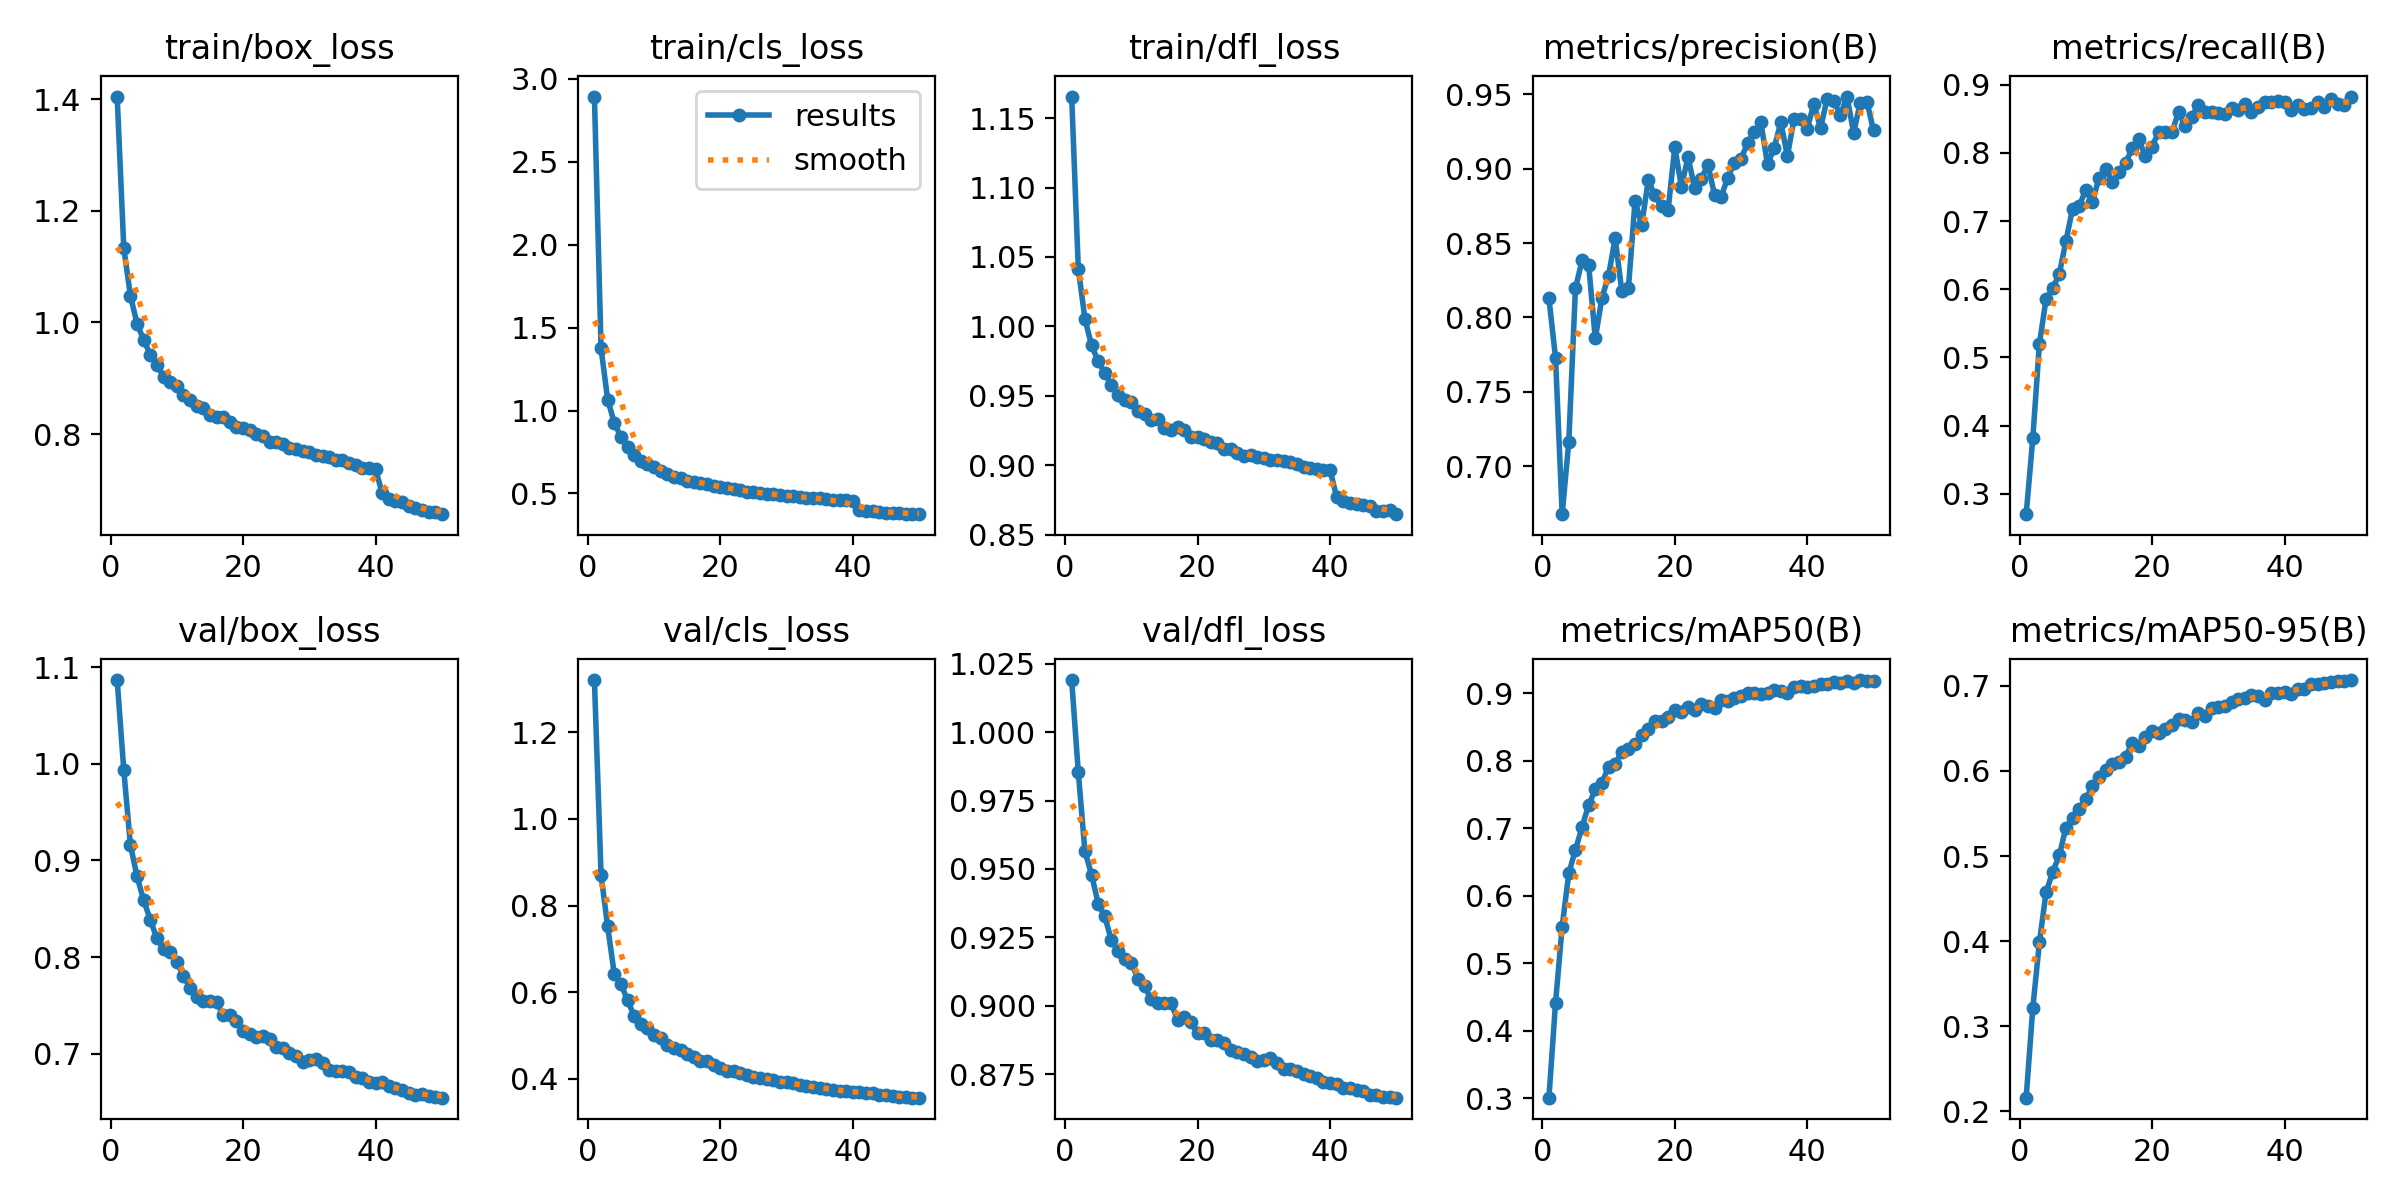

In [9]:
from IPython.display import Image, display

display(Image(filename='/kaggle/working/runs/detect/train/results.png'))

In [10]:
import os

files = os.listdir('/kaggle/working/runs/detect/train')
print(files)

['weights', 'val_batch0_pred.jpg', 'train_batch0.jpg', 'val_batch1_labels.jpg', 'val_batch0_labels.jpg', 'train_batch35001.jpg', 'val_batch1_pred.jpg', 'train_batch35000.jpg', 'train_batch1.jpg', 'train_batch35002.jpg', 'BoxR_curve.png', 'val_batch2_pred.jpg', 'val_batch2_labels.jpg', 'BoxF1_curve.png', 'train_batch2.jpg', 'labels.jpg', 'BoxP_curve.png', 'confusion_matrix.png', 'results.csv', 'results.png', 'confusion_matrix_normalized.png', 'BoxPR_curve.png', 'args.yaml']


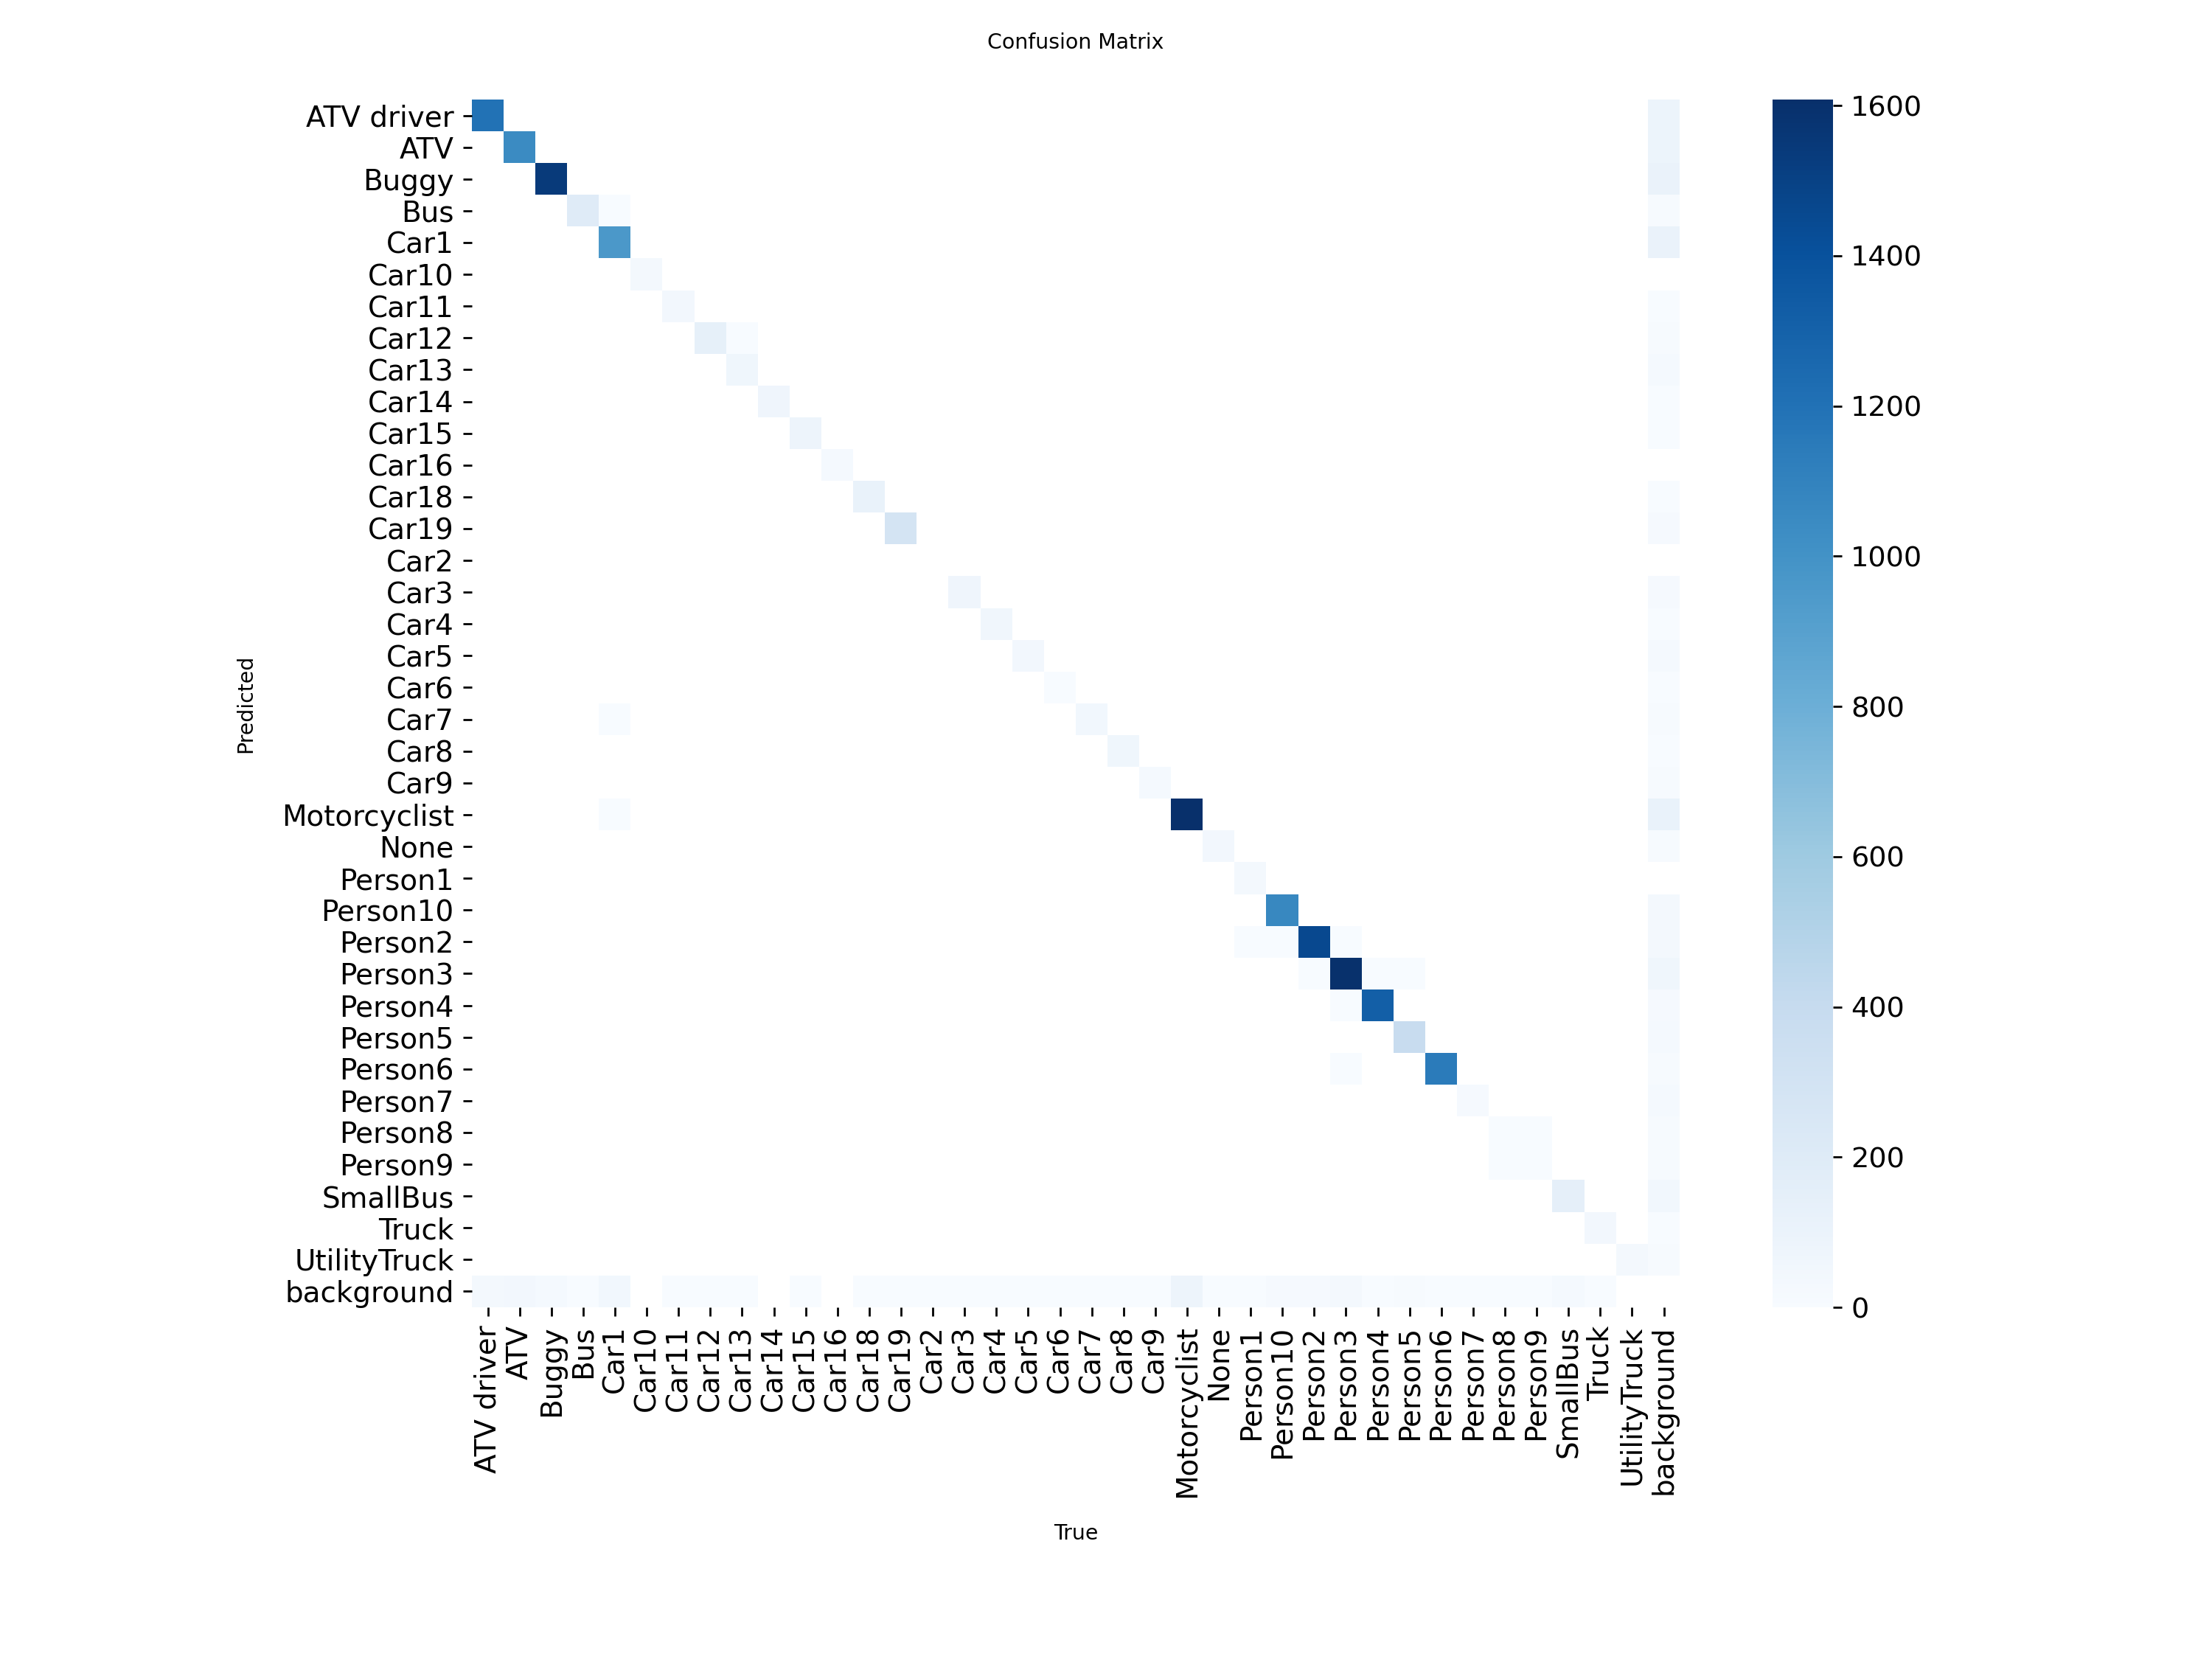

In [12]:
display(Image(filename='/kaggle/working/runs/detect/train/confusion_matrix.png'))

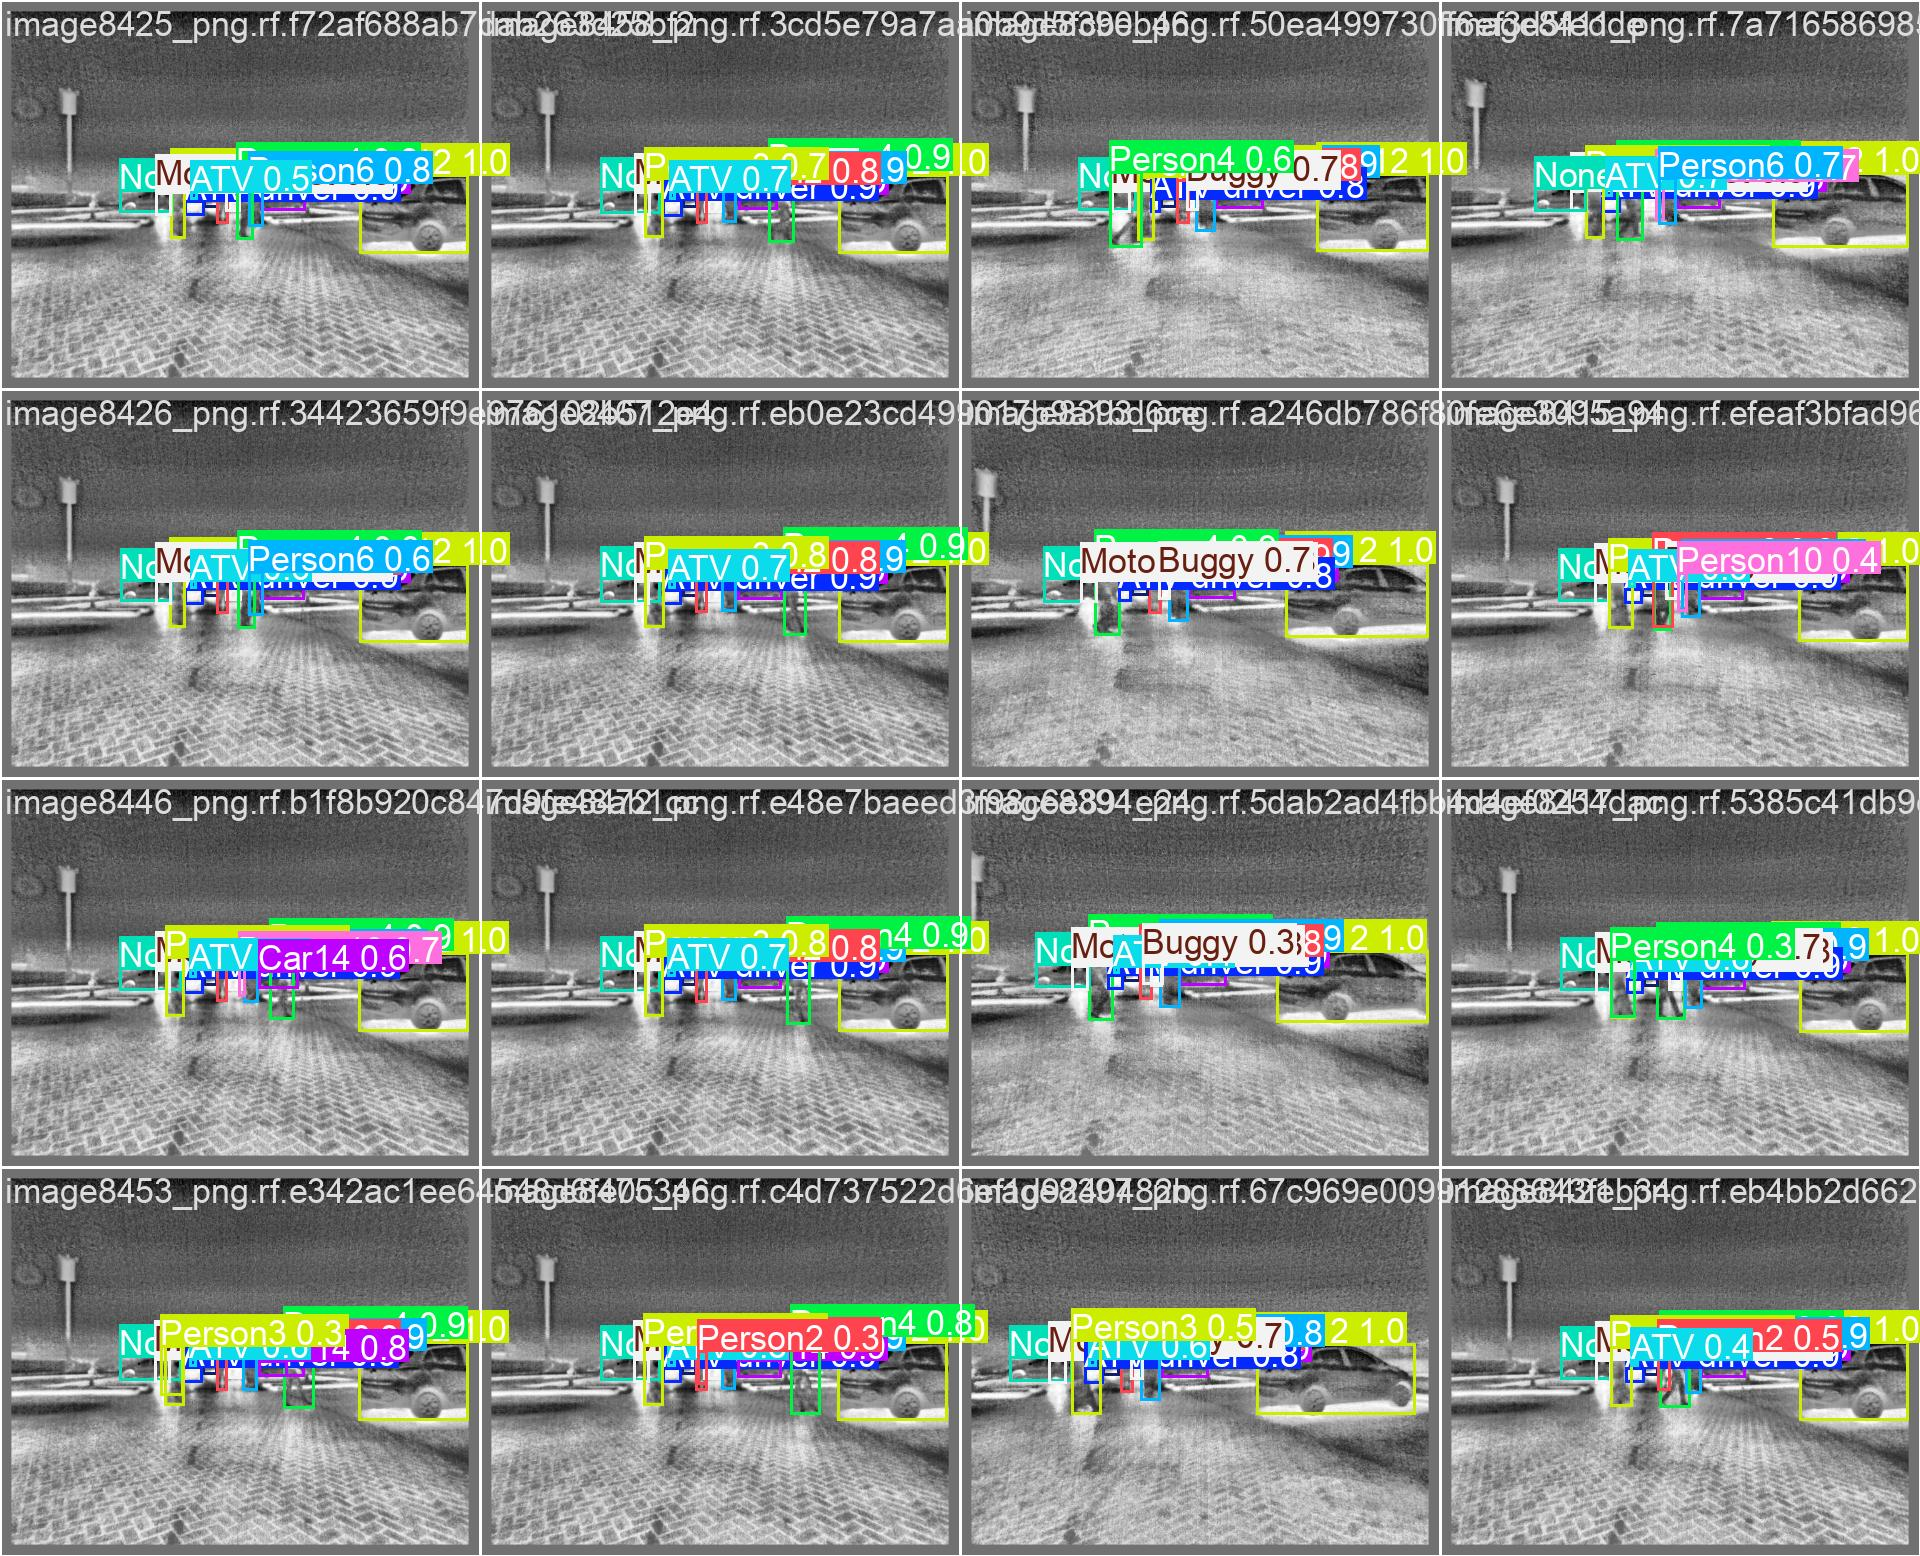

In [13]:
display(Image(filename='/kaggle/working/runs/detect/train/val_batch0_pred.jpg'))

In [15]:
import os

print(os.listdir('/kaggle/working/runs/detect'))

['train']


In [16]:
import os

print(os.listdir('/kaggle/working/runs/detect/train'))

['weights', 'val_batch0_pred.jpg', 'train_batch0.jpg', 'val_batch1_labels.jpg', 'val_batch0_labels.jpg', 'train_batch35001.jpg', 'val_batch1_pred.jpg', 'train_batch35000.jpg', 'train_batch1.jpg', 'train_batch35002.jpg', 'BoxR_curve.png', 'val_batch2_pred.jpg', 'val_batch2_labels.jpg', 'BoxF1_curve.png', 'train_batch2.jpg', 'labels.jpg', 'BoxP_curve.png', 'confusion_matrix.png', 'results.csv', 'results.png', 'confusion_matrix_normalized.png', 'BoxPR_curve.png', 'args.yaml']


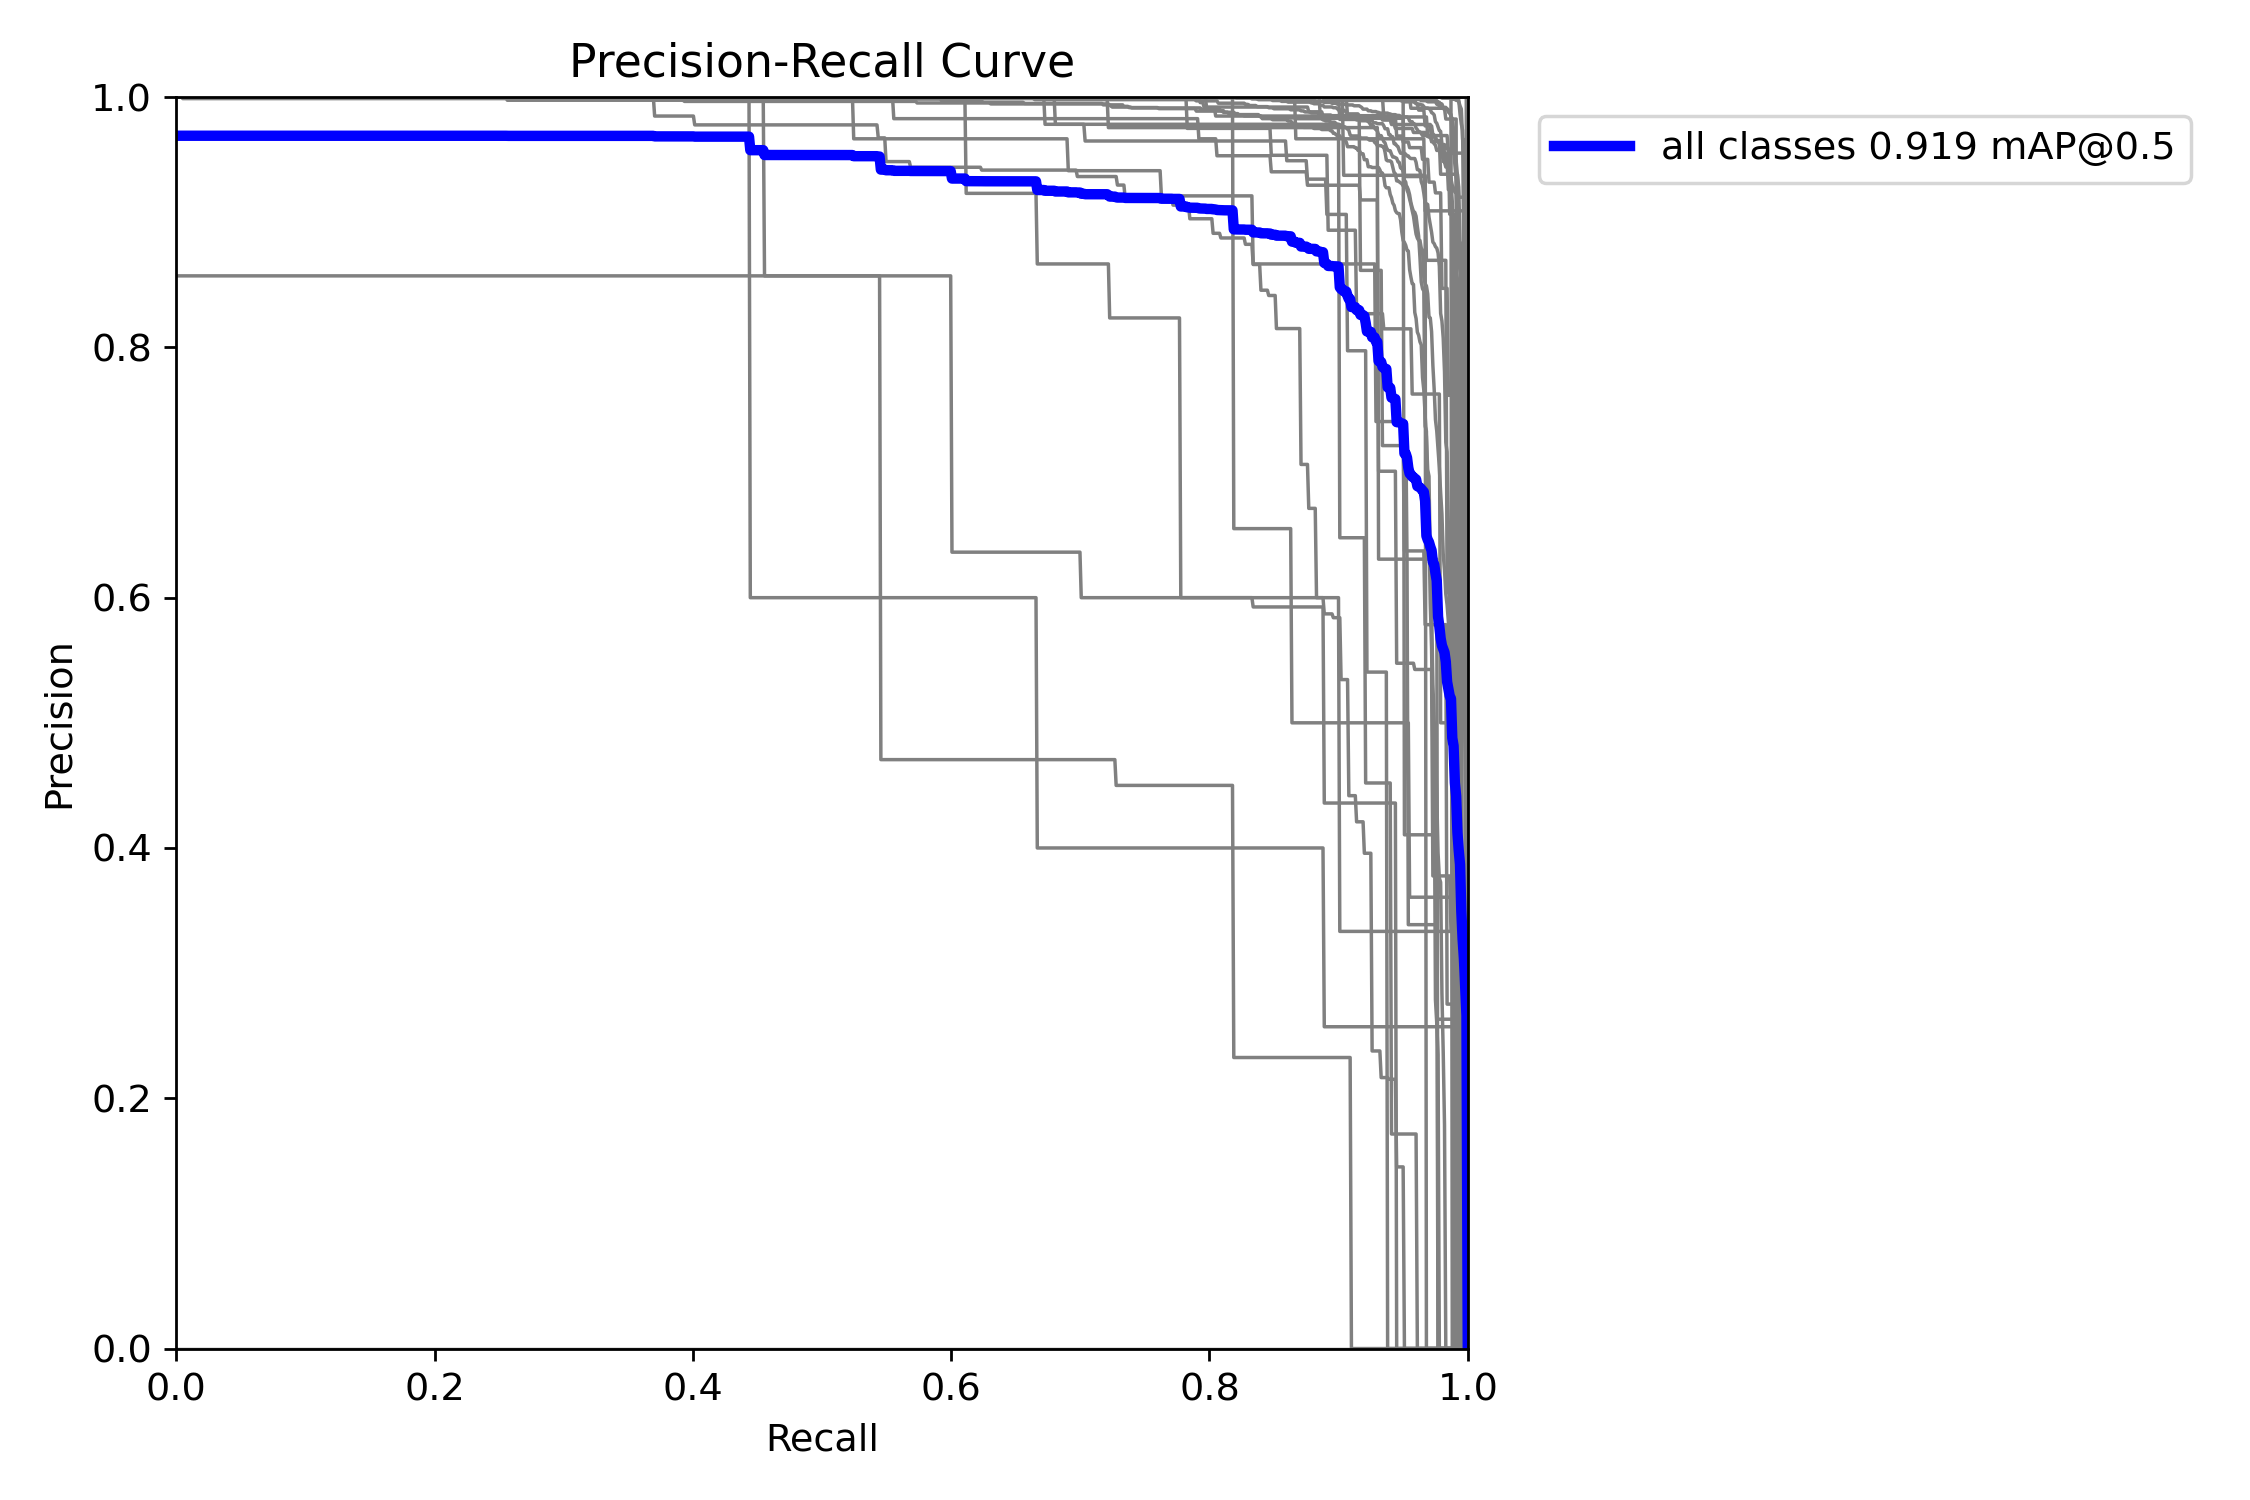

In [17]:
from IPython.display import Image, display

display(Image(filename='/kaggle/working/runs/detect/train/BoxPR_curve.png'))